# Automated Compilation for Dynamic Circuit

Dynamic or adaptive quantum circuits incorporate non-unitary mid-circuit measurements (MCMs) and classical feed-forward control. They are original introduced for quantum error correction for syndrome measurement, but also recently show benefits in reducing circuit depth and quantum resource overhead [1,2,3]. In this tutorial, we will present our method about automated compilation for dynamic circuits that can prepare arbitrary states or unitaries [4].

<img src="images/dynamic_circuit_sample.svg" alt="Diagram" width="500">


**Packages required to run the notebook:**

- `bqskit==1.1.2`
- `qiskit`
- `qiskit_aer`
- `qiskit_qasm3_import`
- `matplotlib`

Contents
-----------
* [Instantiation for dynamic circuit](#Instantiation-for-dynamic-circuit)
* [Synthesis for dynamic circuit](#Synthesis-for-dynamic-circuit)
* [Validation for dynamic circuit](#Validation-for-dynamic-circuit)

## Instantiation for dynamic circuit

### State preparation

<img src="images/state.svg" alt="Diagram" width="500">


We have $s$ system qubits and $a$ ancilla qubits, and we aim to prepare the target state $|T\rangle$ on the system qubits.

Initially, all the $s$ and $a$ qubits are in $|0\rangle$ state. For example we only have 1 ancilla qubit, $U_b$ is applied to all the qubits. If the measurement result is 0, we apply $U_0$, otherwise, we apply $U_1$.

If we have two ancilla qubits, the circuit becomes

<img src="images/2-ancillas.svg" alt="Diagram" width="500">

We already know that the cost function to quantify the distance between a pure quantum state $|\phi\rangle$ to a target state $|T\rangle$ is defined as:

$$
1 - F_{T}(|\phi\rangle) = 1 - |\langle T|\phi\rangle|^2
$$

For dynamic circuit, suppose we have $a$ ancilla qubits, the cost function for state preparation becomes:

$$
C_T = 1 - \sum_i^{2^a} F_T(|\phi_i\rangle) = 1 - \sum_i^{2^a} |\langle T \otimes i |\phi_i\rangle|^2.
$$
where 
$$
|\phi\rangle = (U_i \otimes |i \rangle \langle i|) U_b |0 ^{\otimes(s+a)}\rangle
$$

Example: Given a dynamic circuit structure that can prepare a 3-qubit GHZ state, verify is we can use instantiation with the new cost function to find the optimal parameters.

In [1]:
from utils_dc.dc_instantiation_state import generate_ghz_target_states

n = 4
ancillas = [2] # set the ancilla qubit
target_states = list(generate_ghz_target_states(n, ancillas).values())

In [2]:
# 1/sqrt(2) (|0000> + |1101>) measurement results is 0
target_states[0]

array([0.70710678+0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.70710678+0.j, 0.        +0.j, 0.        +0.j])

In [3]:
# 1/sqrt(2) (|0010> + |1111> measurement result is 1
target_states[1]

array([0.        +0.j, 0.        +0.j, 0.70710678+0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.70710678+0.j])

In [4]:
from bqskit import Circuit
from bqskit.ir.gates import CXGate
from bqskit.ir.gates import U3Gate

n = 4 # 3 data qubits and 1 ancilla qubit

# Step 1: Generate the base circuit Ub
qc = Circuit(n) 
for i in range(4):
    qc.append_gate(U3Gate(), i)
cx_list = [(0, 1), (2, 3), (1, 2),]
for cx_pair in cx_list:
    qc.append_gate(CXGate(), cx_pair)
    qc.append_gate(U3Gate(), cx_pair[0])
    qc.append_gate(U3Gate(), cx_pair[1])

In [5]:
# Step 2: Generate the branch circuits

branch_circuits = []
for _ in target_states: # each target state correspond to one branch circuit
    branch_circuit = Circuit(n)
    for i in range(n):
        if i not in ancillas:
            branch_circuit.append_gate(U3Gate(), i)
    branch_circuits.append(branch_circuit)

In [6]:
# Step 3: Intantiation for state preparation

from utils_dc.dc_instantiation_state import state_instantiation

cost = state_instantiation(qc, branch_circuits, ancillas, target_states)

In [7]:
# represent the distance between the prepared states and the target states
cost

np.float64(4.960134525333615e-10)

### Unitary preparation

<img src="images/unitary.svg" alt="Diagram" width="500">


We have $s$ system qubits and $a$ ancilla qubits, and we aim to prepare the target unitary $V$ on the system qubits.

Initially, all the $a$ qubits are in $|0\rangle$ state while the $s$ qubits can start from arbitrary states. For example we only have 1 ancilla qubit, $U_b$ is applied to all the qubits. If the measurement result is 0, we apply $U_0$, otherwise, we apply $U_1$.


If we have a unitary circuit without MCM or feed-forward operations, the cost function for instantiation is Hilbert-Schmidt distance.
$$
\| U_T - U_S \|_{HS} < \epsilon
$$
where $U_T$ is the target unitary matrix, $U_S$ is the circuit unitary, and $\| \cdot\|_{HS}$ is the Hilbert-Schmidt norm.

For dynamic circuits with $a$ ancilla qubits, we propose two cost functions:
<img src="images/cdyn1.svg" alt="Diagram" width="600">


$$
C_{dyn1} (U,W) = 1 - \frac{1}{2^s} |Tr(f_0 (V \otimes W)^\dagger U)|
$$

where $w$ is a parametrized unitary applied to the ancilla qubits, and $f_0 = I \otimes I \otimes ... I \otimes |0\rangle \langle 0|$ to ensure the ancilla qubits already start from state 0.

We can also analytically remove $w$ and obtain $C_{dyn2}$.
$$
C_{dyn2} (U) = 1 - \frac{1}{4^s}\sum_i ^{2^a} |Tr(U_{i,0} V^\dagger)|^2
$$

Example: given a circuit that can prepare a 3-qubit long-range CNOT, where control qubit and target qubit are $q_0$ and $q_2$, while $q_1$ in the middle is the ancilla qubit. We use $C_{dyn2}$ here

In [8]:
import numpy as np

# target is a CNOT
V = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]])

n = 3 # 2 data qubits and 1 ancilla
ancillas = [1] # set the middle qubit as the ancilla

In [9]:
# Step1 : Generate the base circuit
qc = Circuit(n)
for i in range(n):
    qc.append_gate(U3Gate(), i)
cx_list = [(0, 1), (1, 2)]
for cx_pair in cx_list:
    qc.append_gate(CXGate(), cx_pair)
    qc.append_gate(U3Gate(), cx_pair[0])
    qc.append_gate(U3Gate(), cx_pair[1])

In [10]:
# Step 2: Generate the branch circuits

branch_circuits = []
for _ in range(2**len(ancillas)): # each target state correspond to one branch circuit
    branch_circuit = Circuit(n)
    for i in range(n):
        if i not in ancillas:
            branch_circuit.append_gate(U3Gate(), i)
    branch_circuits.append(branch_circuit)

In [11]:
# Step 3: Intantiation for unitary preparation

from utils_dc.dc_instantiation_unitary import unitary_instantiation

cost = unitary_instantiation(qc, branch_circuits, ancillas, V)

In [12]:
# represent the distance between the prepared unitary and the target unitary
cost

np.float64(1.1156964241365586e-11)

## Synthesis for dynamic circuit

### State preparation
Here we will show an example of preparing the 3-qubit GHZ state using synthesis.

It requires the target states, branch circuits, and coupling graph as input.

In [13]:
from utils_dc.dc_instantiation_state import generate_ghz_target_states

n = 4
ancillas = [2] # set the ancilla qubit
target_states = list(generate_ghz_target_states(n, ancillas).values())
# Suppose we have linear connectivity
coupling_graph = [(i, i+1) for i in range(n - 1)]

In [14]:
# Generate branch circuits
branch_circuits = []
for _ in target_states: # each target state correspond to one branch circuit
    branch_circuit = Circuit(n)
    for i in range(n):
        if i not in ancillas:
            branch_circuit.append_gate(U3Gate(), i)
    branch_circuits.append(branch_circuit)

In [15]:
from utils_dc.state_synthesis import StateSynthesisPass, set_params_circuits

synthesizer = StateSynthesisPass(branch_circuits)
qc, best_params = synthesizer.synthesize(target_states, ancillas, coupling_graph, initial_layer=None)
set_params_circuits(qc, branch_circuits, best_params)

final dist: 4.668909703298141e-11


In [16]:
print(qc.to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
u3(-1.5707950545918243, -0.42387023077317115, 2.1989571898222886) q[0];
u3(9.307560021172386e-07, -2.5024635016994354, 0.39744336937608854) q[1];
u3(-1.5707977599443075, -0.13941420423846296, -1.6725177523896633) q[2];
u3(3.1415979527709523, 0.9133787338078038, -1.1183860024415462) q[3];
cx q[0], q[1];
cx q[2], q[3];
u3(1.7695588504384108, -0.4372354423460594, -2.7799143852839916) q[0];
u3(0.09948797486126251, 3.09962281478564, 3.2383213554194183) q[1];
u3(0.15915307689817418, -2.7018235959929644, -1.87276774779422) q[2];
u3(2.5977613732226428, 0.5532006025504465, 0.24529451395904045) q[3];
cx q[1], q[2];
u3(-0.15727809421982836, 2.3126200645390997, 0.0950582755985575) q[1];
u3(0.45807341398542173, -1.7667560511813092, 1.5707961426353398) q[2];



In [17]:
print(branch_circuits[0].to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
u3(-1.272603048399702, -0.007910286622504353, -2.7079383466496076) q[0];
u3(3.2988662979393983, 3.299269538662537, -2.312607556476595) q[1];
u3(-3.1415889977804787, -0.11276636231939241, 1.2468965864975377) q[3];



In [18]:
print(branch_circuits[1].to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
u3(-1.8689863971877978, 2.17671177614044, 0.43364739379699874) q[0];
u3(-0.15728076744325936, 0.4470401386963112, 0.8290063228583452) q[1];
u3(3.141584952217672, 2.1981540342134847, -3.2159166408974538) q[3];



In [19]:
program = """
OPENQASM 3.0;
include "stdgates.inc";
qubit[4] q;
bit[1] mid;
bit[3] out;

u3(1.5707952286543603, 1.453503161726315, -0.7097174488354816) q[0];
u3(1.6139527337193365, -1.5707962955119756, -2.478495989188278) q[1];
u3(1.5707978430017353, 2.2192872423529315, 2.7910202417005348) q[2];
u3(1.6620415268968436, -1.5707949118118156, -0.08047268447264926) q[3];
cx q[0], q[1];
cx q[2], q[3];
u3(-0.5053840548451003, 3.1908243564657472, 2.0657104902839074) q[0];
u3(0.9341134334268166, -0.51753553901209, -2.0979396244662816) q[1];
u3(1.2380473112183168, 0.8771160675759744, -2.681553048302417) q[2];
u3(-1.4623466320094656, -2.356570374492616, -1.3949954906908386) q[3];
cx q[1], q[2];
u3(0.859199644314671, 2.3186434225587496, -1.2550894836462543) q[1];
u3(3.2773596814691466, 0.44816160002302735, -1.570790683419668) q[2];


mid[0] = measure q[2];
if (mid == 0){
u3(-1.8667138448277671, -2.738234703136492, -2.7235724981672496) q[0];
u3(4.000797709569341, -1.5783295029771909, 0.8229506634329754) q[1];
u3(1.9354463575672787, -2.6538935338785867, -2.958153677655454) q[3];
}
if (mid == 1){
u3(1.2748861874834212, 2.5195707113518133, -2.7235780462323325) q[0];
u3(-0.8591960619622244, -0.003874898052322371, -2.3186354050093905) q[1];
u3(-1.9354476956700835, 2.421917337749236, 0.1834457034840376) q[3];
}
barrier q;
out[0] = measure q[0];
out[1] = measure q[1];
out[2] = measure q[3];
"""

In [20]:
import qiskit.qasm3

qc_ghz = qiskit.qasm3.loads(program)

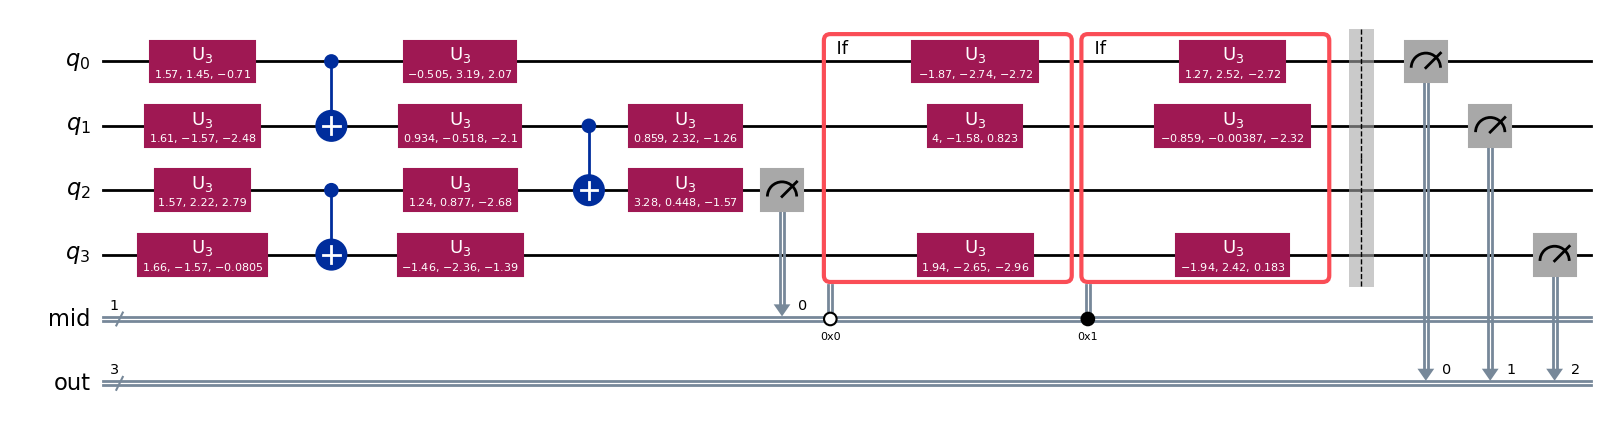

In [21]:
qc_ghz.draw(output='mpl')

### Unitary preparation
Here we will show an example of preparing the 3-qubit long-range CNOT using synthesis.

It requires the target states, branch circuits, and coupling graph as input.

In [22]:
n = 3 # 2 data qubits and 1 ancilla
ancillas = [1] # the middle qubit is the ancilla qubit
coupling_graph = [(i, i+1) for i in range(n - 1)]

# Generate branch circuits
branch_circuits = []
for _ in range(2 ** len(ancillas)): # each target state correspond to one branch circuit
    branch_circuit = Circuit(n)
    for i in range(n):
        if i not in ancillas:
            branch_circuit.append_gate(U3Gate(), i)
    branch_circuits.append(branch_circuit)

In [23]:
# target CNOT unitary
V = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]])

In [24]:
from utils_dc.unitary_synthesis_cdyn2 import UnitarySynthesisPass, set_params_circuits

synthesizer = UnitarySynthesisPass(branch_circuits)
qc, best_params = synthesizer.synthesize(V, ancillas, coupling_graph, initial_layer=None)
set_params_circuits(qc, branch_circuits, best_params)

/Users/siyuanniu/UCF/project/bqskit-tutorial/utils_dc/unitary_synthesis_cdyn2.py:393: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m, y_int, _, _, _ = linregress(best_layers, best_dists)


final dist: 3.106626067506113e-12


In [25]:
print(qc.to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
u3(3.1415928945810943, -1.1066311880837687, -0.035757376456497715) q[0];
u3(3.9955505165846046, 1.5707954511127757, -0.15777217787095374) q[1];
u3(-3.141591522017573, 0.8915988947496042, 0.8915973652273976) q[2];
cx q[0], q[1];
u3(3.1415916622250037, 0.9805954088292539, 0.280786627249122) q[0];
u3(-0.7771078455220266, -2.6885299230017794, -0.5343720392671032) q[1];
cx q[1], q[2];
u3(-1.5707973701366609, 1.2891495711553385, 2.40795173611698) q[1];
u3(0.7764124985615485, -1.143703256429347, 4.534575981755685) q[2];



In [26]:
print(branch_circuits[0].to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
u3(-3.217039262102856e-06, -0.3735579296263942, 2.850146119569383) q[0];
u3(-1.6314308712412287, 1.4463041348241548, -1.8779563522332794) q[2];



In [27]:
print(branch_circuits[1].to('qasm'))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
u3(-2.5854472735416887e-06, 2.4535718366492643, -3.1185752010966055) q[0];
u3(3.2687924833453814, 0.2147606445128667, -3.224713103753804) q[2];



In [28]:
program = """
OPENQASM 3.0;
include "stdgates.inc";
qubit[3] q;
bit[1] mid;
bit[2] out;

u3(-3.141593484726783, -1.8855615336991065, -1.4418447898151252) q[0];
u3(1.6613947729796825, 1.570796837819715, -0.9739175110503411) q[1];
u3(4.077120846428939, 1.5707958680400518, -1.5707957110571713) q[2];
cx q[0], q[1];
u3(-3.1415940462236813, -1.2043946801336003, -2.4347986364245107) q[0];
u3(-0.24382096581601848, 2.856403738308569, -1.656156332155718) q[1];
cx q[1], q[2];
u3(1.5707981605001855, -2.8551378646997243, -1.1996010796184884) q[1];
u3(-0.29584648194461577, 1.5608443329549055, 2.1320019680392397) q[2];

mid[0] = measure q[1];
if (mid == 0){
u3(-1.8716402400616054e-06, -2.086599109950612, -2.7082895088547416) q[0];
u3(-0.277351001007689, -0.9683184526368546, 3.596537206626135) q[2];
}
if (mid == 1){
u3(-1.1478677911477486e-06, 0.10179960709010773, -1.7550960310993522) q[0];
u3(-2.5864261334907903, 1.2719829450818938, 0.7833294272773256) q[2];
}
barrier q;
out[0] = measure q[0];
out[1] = measure q[2];
"""

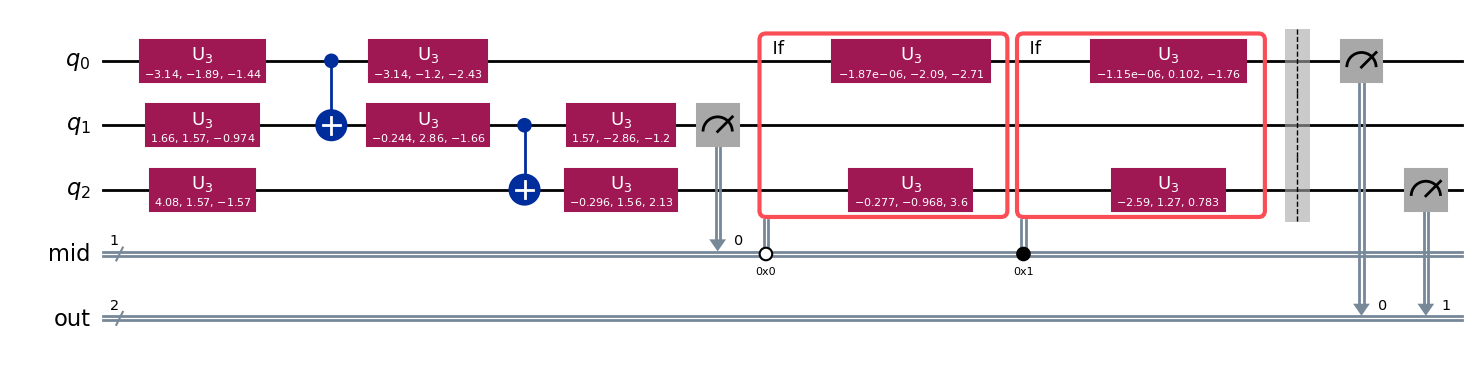

In [29]:
qc_cx = qiskit.qasm3.loads(program)
qc_cx.draw(output='mpl')

## Validation for dynamic circuit

### State validation
Here we validate if the synthesized circuit can indeed prepare a 3-qubit GHZ state

In [30]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
job = sim.run(qc_ghz)

counts = job.result().get_counts()

In [31]:
counts

{'111 0': 273, '000 1': 232, '111 1': 278, '000 0': 241}

### Unitary validation
Here we validate if the synthesized circuit can prepare a long-range CNOT between $q_0$ and $q_2$.
To do this, we use truth table tomography by preparing the input state of $q_0q_2$ as the compputational basis states: $|00\rangle, |01\rangle, |10\rangle, |11\rangle$.

In [32]:
from qiskit import QuantumCircuit

qc_00 = QuantumCircuit(3)
qc_00.barrier()
qc_00.compose(qc_cx, inplace=True)

qc_01 = QuantumCircuit(3)
qc_01.x(2)
qc_01.barrier()
qc_01.compose(qc_cx, inplace=True)

qc_10 = QuantumCircuit(3)
qc_10.x(0)
qc_10.barrier()
qc_10.compose(qc_cx, inplace=True)

qc_11= QuantumCircuit(3)
qc_11.x(0)
qc_11.x(2)
qc_11.barrier()
qc_11.compose(qc_cx, inplace=True)

If we succeed preparing a CNOT gate,

when input is $|00\rangle$, output should be $|00\rangle$;

when input is $|01\rangle$, output should be $|01\rangle$;

when input is $|10\rangle$, output should be $|11\rangle$;

when input is $|11\rangle$, output should be $|10\rangle$.

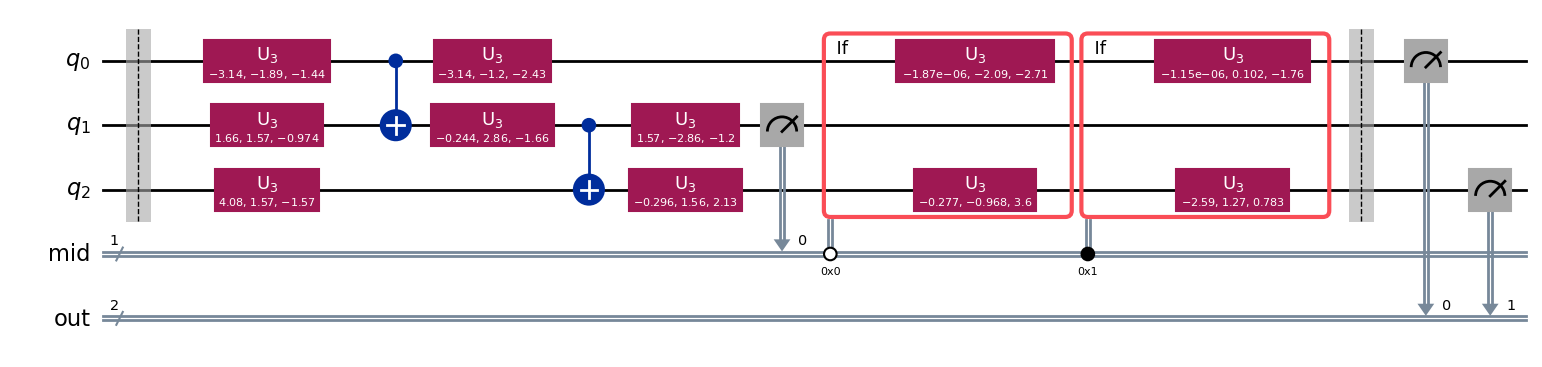

In [33]:
qc_00.draw(output='mpl')

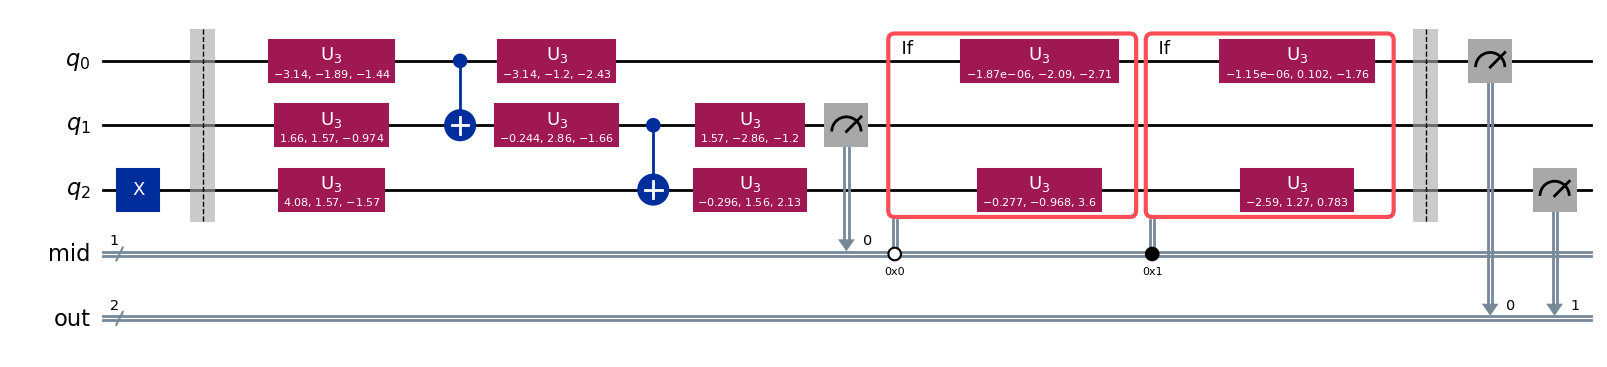

In [34]:
qc_01.draw(output='mpl')

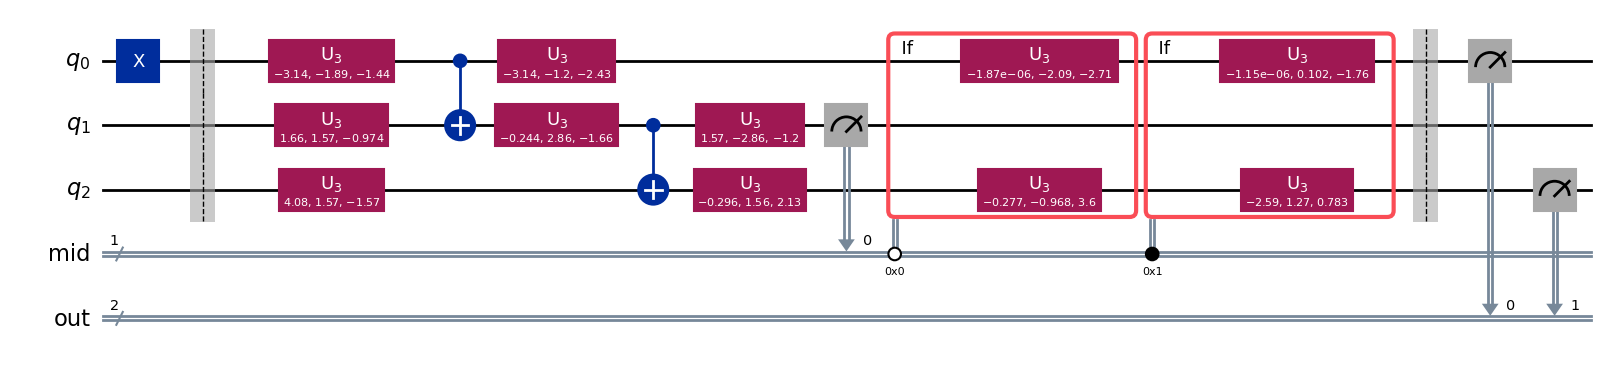

In [35]:
qc_10.draw(output='mpl')

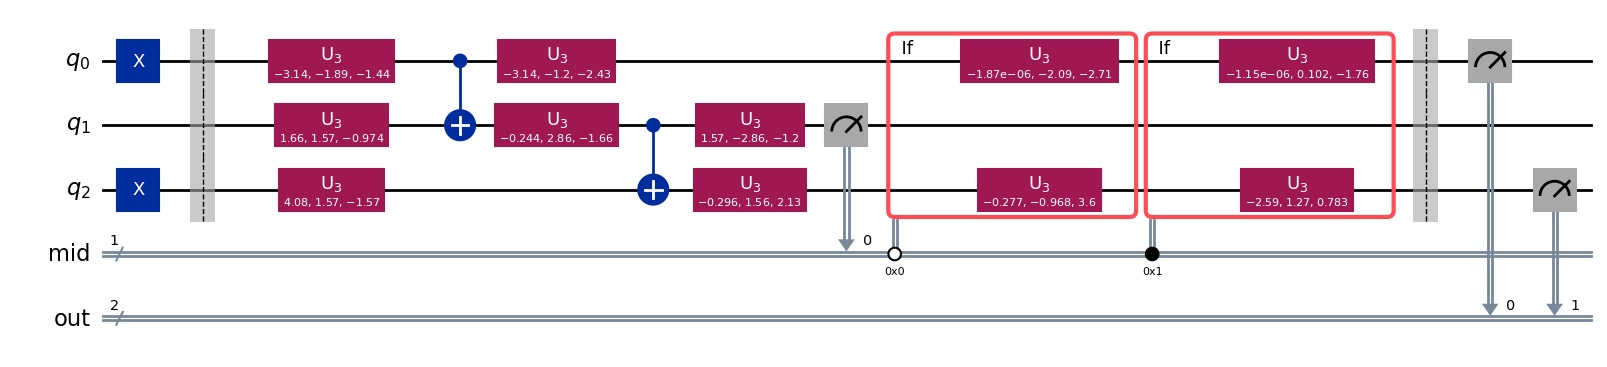

In [36]:
qc_11.draw(output='mpl')

In [37]:
job = sim.run([qc_00, qc_01, qc_10, qc_11])
res = job.result().get_counts()

In [38]:
initial_states = ['00', '01', '10', '11']

for r, initial_state in zip(res, initial_states):
    print(f'---initial state {initial_state} ----')
    print(r)

---initial state 00 ----
{'00 1': 530, '00 0': 494}
---initial state 01 ----
{'10 0': 497, '10 1': 527}
---initial state 10 ----
{'11 0': 499, '11 1': 525}
---initial state 11 ----
{'01 0': 520, '01 1': 504}


## References
-------------
[1] https://arxiv.org/abs/2308.13065, E. Baumer, et al., "Efficient Long-Range Entanglement using Dynamic Circuits"
<br>[2] https://arxiv.org/abs/2404.16083, K. Smith, et al., "Constant-depth preparation of matrix product states with adaptive quantum circuits"
<br>[3] https://arxiv.org/abs/2410.09030, F. Alam, et al., "Learning dynamic quantum circuits for efficient state preparation"
<br>[4] https://arxiv.org/abs/2412.07969, S. Niu, et al., "AC/DC: Automated Compilation for Dynamic Circuits"